In [2]:
import pandas as pd
import random

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


In [6]:
dataset=pd.read_csv("fashion_customer_churn.csv")

In [7]:
dataset

,CustomerID,Gender,Age,City,MembershipType,PreferredCategory,BrandPreference,TotalOrders,TotalSpent,AverageOrderValue,...,SaleEventParticipation,ReturnCount,ExchangeCount,SizeIssueReturns,CancelCount,RefundRequests,DeliveryDelayCount,SupportTickets,SatisfactionScore,Churn
0,C1001,Male,18,Pune,Silver,Women,Adidas,9,48765,5418.33,...,0,0,1,0,1,4,4,0,3.2,No
1,C1002,Female,25,Mumbai,Gold,Kids,H&M,49,10963,223.73,...,1,6,1,2,2,4,2,0,3.9,No
2,C1003,Male,30,Chennai,Gold,Kids,Levis,37,13101,354.08,...,6,4,7,2,1,2,2,3,3.7,No
3,C1004,Male,37,Pune,Free,Footwear,Adidas,11,30794,2799.45,...,3,0,5,0,2,0,1,5,1.9,Yes
4,C1005,Female,30,Pune,Silver,Women,Puma,9,16662,1851.33,...,3,2,8,1,0,0,6,1,1.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,C1496,Female,25,Bangalore,Gold,Footwear,Zara,10,37652,3765.20,...,7,1,7,1,1,2,1,1,2.1,Yes
496,C1497,Female,29,Chennai,Free,Women,U.S. Polo,17,31515,1853.82,...,0,5,4,3,3,4,5,2,2.8,Yes
497,C1498,Female,29,Chennai,Gold,Beauty,U.S. Polo,17,45231,2660.65,...,2,1,4,1,1,4,3,1,1.9,No
498,C1499,Female,39,Chennai,Silver,Beauty,U.S. Polo,42,35569,846.88,...,6,5,1,2,2,4,3,3,3.8,No


In [8]:
dataset=pd.get_dummies(dataset,drop_first=True)

In [9]:
dataset

,Age,TotalOrders,TotalSpent,AverageOrderValue,LastPurchaseDaysAgo,PurchaseFrequencyPerMonth,AppLoginFrequency,ProductViews,WishlistCount,CartAdditions,...,PreferredCategory_Men,PreferredCategory_Women,BrandPreference_H&M,BrandPreference_Levis,BrandPreference_Nike,BrandPreference_Puma,BrandPreference_Roadster,BrandPreference_U.S. Polo,BrandPreference_Zara,Churn_Yes
0,18,9,48765,5418.33,27,5.48,29,284,2,18,...,False,True,False,False,False,False,False,False,False,False
1,25,49,10963,223.73,179,3.50,9,84,6,10,...,False,False,True,False,False,False,False,False,False,False
2,30,37,13101,354.08,18,0.56,8,153,2,7,...,False,False,False,True,False,False,False,False,False,False
3,37,11,30794,2799.45,98,2.31,30,290,7,10,...,False,False,False,False,False,False,False,False,False,True
4,30,9,16662,1851.33,144,4.40,24,224,18,12,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,25,10,37652,3765.20,161,7.96,4,12,4,9,...,False,False,False,False,False,False,False,False,True,True
496,29,17,31515,1853.82,66,6.15,15,76,3,18,...,False,True,False,False,False,False,False,True,False,True
497,29,17,45231,2660.65,11,5.04,21,34,23,7,...,False,False,False,False,False,False,False,True,False,False
498,39,42,35569,846.88,120,1.05,6,60,12,13,...,False,False,False,False,False,False,False,True,False,False


In [12]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plti

In [13]:
# Load dataset
df = pd.read_csv("fashion_customer_churn.csv")

In [14]:
# Show first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
  CustomerID  Gender  Age     City MembershipType PreferredCategory  \
0      C1001    Male   18     Pune         Silver             Women   
1      C1002  Female   25   Mumbai           Gold              Kids   
2      C1003    Male   30  Chennai           Gold              Kids   
3      C1004    Male   37     Pune           Free          Footwear   
4      C1005  Female   30     Pune         Silver             Women   

  BrandPreference  TotalOrders  TotalSpent  AverageOrderValue  ...  \
0          Adidas            9       48765            5418.33  ...   
1             H&M           49       10963             223.73  ...   
2           Levis           37       13101             354.08  ...   
3          Adidas           11       30794            2799.45  ...   
4            Puma            9       16662            1851.33  ...   

   SaleEventParticipation  ReturnCount  ExchangeCount  SizeIssueReturns  \
0                       0            0              1          

In [15]:
# Dataset info
print("\nDataset Shape:", df.shape)
print("\nChurn Distribution:")
print(df["Churn"].value_counts())


Dataset Shape: (500, 27)

Churn Distribution:
Churn
No     359
Yes    141
Name: count, dtype: int64


In [16]:
# Drop CustomerID
if "CustomerID" in df.columns:
    df = df.drop("CustomerID", axis=1)

In [17]:
# Encode categorical columns
label_encoders = {}
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

In [19]:
# Remove target column from feature encoding
if "Churn" in categorical_cols:
    categorical_cols.remove("Churn")

In [20]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

This code converts text columns into numbers so the Machine Learning model can understand them.

Because ML models cannot directly understand words like:

Male
Female
Chennai
Gold
Women

So we convert them into numbers like:

Male → 1
Female → 0

**This code:
takes every text column
converts text into numbers
saves each column’s conversion rule
so model training and future prediction use the same mapping**

In [21]:
# Encode target column
target_encoder = LabelEncoder()
df["Churn"] = target_encoder.fit_transform(df["Churn"])   # No=0, Yes=1 usually

In [22]:
# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [25]:
# Train-test split
X_train, X_test, y_train,
y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

| Variable  | Meaning               |
| --------- | --------------------- |
| `X_train` | Training input data   |
| `X_test`  | Testing input data    |
| `y_train` | Training output/label |
| `y_test`  | Testing output/label  |


**X_train**

This stores the training input features

This is the 80% feature data used to train the model.

Example:

Columns like:

Age
City
MembershipType
TotalOrders
LastPurchaseDaysAgo
SatisfactionScore

---------------
**X_test**

Meaning:

This stores the testing input features

This is the 20% feature data used to test the model.

The model has not seen this data before.
---------------
**y_train**

Meaning:

This stores the training target/output labels

This is the 80% churn values used during training.

Example:

Yes / No
or
1 / 0

---------------

**y_test**
Meaning:

This stores the testing target/output labels

👉 This is the actual correct answers for the test data.

We compare:

y_pred (model prediction)
with
y_test (real answer)

to calculate accuracy.




*test_size=0.2*

Meaning:

Use 20% data for testing

So:

80% → training
20% → testing

Example:

If dataset has 500 rows:

400 rows → training
100 rows → testing

This is the most common split.

**stratify=y**
This line splits the feature data and target data into training and testing sets, where 80% is used to train the model and 20% is used to test it.

random_state=42 ensures the same split every run, and stratify=y keeps the churn class distribution balanced in both sets.

In [26]:
# Train Random Forest model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [36]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f}")


✅ Accuracy: 0.8700


In [37]:
# Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92        72
           1       0.94      0.57      0.71        28

    accuracy                           0.87       100
   macro avg       0.90      0.78      0.81       100
weighted avg       0.88      0.87      0.86       100



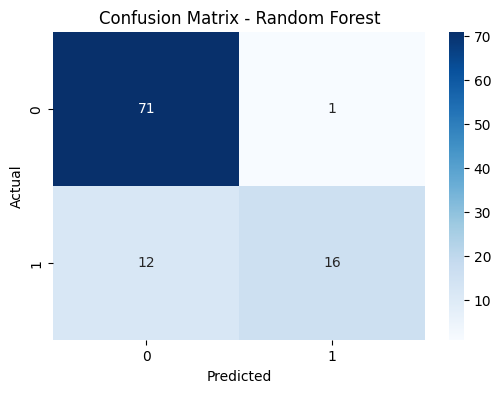

In [38]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
# Save files
pickle.dump(model, open("fashion_churn_rf_model.pkl", "wb"))
pickle.dump(label_encoders, open("fashion_rf_label_encoders.pkl", "wb"))
pickle.dump(target_encoder, open("fashion_rf_target_encoder.pkl", "wb"))

In [41]:
print("\n✅ Model and encoders saved successfully!")


✅ Model and encoders saved successfully!


In [43]:
import pandas as pd
import pickle

# Load saved model and encoders
model = pickle.load(open("fashion_churn_rf_model.pkl", "rb"))
label_encoders = pickle.load(open("fashion_rf_label_encoders.pkl", "rb"))
target_encoder = pickle.load(open("fashion_rf_target_encoder.pkl", "rb"))

# Create one sample customer input
sample_customer = pd.DataFrame([{
    "Gender": "Female",
    "Age": 24,
    "City": "Chennai",
    "MembershipType": "Gold",
    "PreferredCategory": "Women",
    "BrandPreference": "H&M",
    "TotalOrders": 18,
    "TotalSpent": 24500,
    "AverageOrderValue": 1361.11,
    "LastPurchaseDaysAgo": 15,
    "PurchaseFrequencyPerMonth": 3.2,
    "AppLoginFrequency": 20,
    "ProductViews": 120,
    "WishlistCount": 14,
    "CartAdditions": 10,
    "CouponUsageCount": 8,
    "SaleEventParticipation": 4,
    "ReturnCount": 1,
    "ExchangeCount": 1,
    "SizeIssueReturns": 0,
    "CancelCount": 0,
    "RefundRequests": 0,
    "DeliveryDelayCount": 1,
    "SupportTickets": 1,
    "SatisfactionScore": 4.5
}])

# Encode categorical columns using saved encoders
for col in sample_customer.columns:
    if col in label_encoders:
        sample_customer[col] = label_encoders[col].transform(sample_customer[col])

# Predict
prediction = model.predict(sample_customer)[0]
result = target_encoder.inverse_transform([prediction])[0]

print("Prediction:", result)

if result == "Yes":
    print("⚠️ Customer is likely to CHURN")
else:
    print("✅ Customer is likely to STAY")

Prediction: No
✅ Customer is likely to STAY


In [44]:
import pandas as pd

high_risk_customer = pd.DataFrame([{
    "Gender": "Male",
    "Age": 30,
    "City": "Mumbai",
    "MembershipType": "Free",
    "PreferredCategory": "Men",
    "BrandPreference": "Nike",
    "TotalOrders": 3,
    "TotalSpent": 2500,
    "AverageOrderValue": 833.33,
    "LastPurchaseDaysAgo": 140,
    "PurchaseFrequencyPerMonth": 0.5,
    "AppLoginFrequency": 2,
    "ProductViews": 10,
    "WishlistCount": 1,
    "CartAdditions": 0,
    "CouponUsageCount": 0,
    "SaleEventParticipation": 0,
    "ReturnCount": 6,
    "ExchangeCount": 2,
    "SizeIssueReturns": 3,
    "CancelCount": 3,
    "RefundRequests": 3,
    "DeliveryDelayCount": 2,
    "SupportTickets": 5,
    "SatisfactionScore": 2.1
}])

# Encode
for col in high_risk_customer.columns:
    if col in label_encoders:
        high_risk_customer[col] = label_encoders[col].transform(high_risk_customer[col])

# Predict
prediction = model.predict(high_risk_customer)[0]
result = target_encoder.inverse_transform([prediction])[0]

print("Prediction:", result)

if result == "Yes":
    print("⚠️ Customer is likely to CHURN")
else:
    print("✅ Customer is likely to STAY")

Prediction: Yes
⚠️ Customer is likely to CHURN


Dataset generated
✅ Model trained
✅ Accuracy = 87%
✅ Normal customer prediction = STAY
✅ High-risk customer prediction = CHURN

This means your core ML capstone is already successful

In [45]:
import pandas as pd
import pickle

# Load saved model and encoders
model = pickle.load(open("fashion_churn_rf_model.pkl", "rb"))
label_encoders = pickle.load(open("fashion_rf_label_encoders.pkl", "rb"))
target_encoder = pickle.load(open("fashion_rf_target_encoder.pkl", "rb"))

# ---------- CHANGE THESE VALUES TO TEST ----------
gender = "Female"
age = 26
city = "Chennai"
membership_type = "Gold"
preferred_category = "Women"
brand_preference = "Zara"
total_orders = 20
total_spent = 28000
average_order_value = 1400.0
last_purchase_days_ago = 20
purchase_frequency_per_month = 3.5
app_login_frequency = 18
product_views = 150
wishlist_count = 12
cart_additions = 9
coupon_usage_count = 7
sale_event_participation = 5
return_count = 1
exchange_count = 0
size_issue_returns = 0
cancel_count = 0
refund_requests = 0
delivery_delay_count = 1
support_tickets = 1
satisfaction_score = 4.6
# -----------------------------------------------

# Create input dataframe
input_data = pd.DataFrame([{
    "Gender": gender,
    "Age": age,
    "City": city,
    "MembershipType": membership_type,
    "PreferredCategory": preferred_category,
    "BrandPreference": brand_preference,
    "TotalOrders": total_orders,
    "TotalSpent": total_spent,
    "AverageOrderValue": average_order_value,
    "LastPurchaseDaysAgo": last_purchase_days_ago,
    "PurchaseFrequencyPerMonth": purchase_frequency_per_month,
    "AppLoginFrequency": app_login_frequency,
    "ProductViews": product_views,
    "WishlistCount": wishlist_count,
    "CartAdditions": cart_additions,
    "CouponUsageCount": coupon_usage_count,
    "SaleEventParticipation": sale_event_participation,
    "ReturnCount": return_count,
    "ExchangeCount": exchange_count,
    "SizeIssueReturns": size_issue_returns,
    "CancelCount": cancel_count,
    "RefundRequests": refund_requests,
    "DeliveryDelayCount": delivery_delay_count,
    "SupportTickets": support_tickets,
    "SatisfactionScore": satisfaction_score
}])

# Encode categorical columns
for col in input_data.columns:
    if col in label_encoders:
        input_data[col] = label_encoders[col].transform(input_data[col])

# Predict
prediction = model.predict(input_data)[0]
result = target_encoder.inverse_transform([prediction])[0]

print("🛍️ Fashion E-commerce Customer Churn Prediction")
print("===============================================")

print("\nCustomer Input Summary:")
print(f"Gender: {gender}")
print(f"Age: {age}")
print(f"City: {city}")
print(f"Membership Type: {membership_type}")
print(f"Preferred Category: {preferred_category}")
print(f"Brand Preference: {brand_preference}")
print(f"Last Purchase Days Ago: {last_purchase_days_ago}")
print(f"App Login Frequency: {app_login_frequency}")
print(f"Satisfaction Score: {satisfaction_score}")

print("\nPrediction Result:")
print("Prediction:", result)

if result == "Yes":
    print("⚠️ Customer is likely to CHURN")
    print("Suggested Action: Offer discount coupon / personalized recommendations / loyalty reward")
else:
    print("✅ Customer is likely to STAY")
    print("Suggested Action: Continue regular engagement and premium offers")

🛍️ Fashion E-commerce Customer Churn Prediction

Customer Input Summary:
Gender: Female
Age: 26
City: Chennai
Membership Type: Gold
Preferred Category: Women
Brand Preference: Zara
Last Purchase Days Ago: 20
App Login Frequency: 18
Satisfaction Score: 4.6

Prediction Result:
Prediction: No
✅ Customer is likely to STAY
Suggested Action: Continue regular engagement and premium offers


In [46]:
from google.colab import files

files.download("fashion_churn_rf_model.pkl")
files.download("fashion_rf_label_encoders.pkl")
files.download("fashion_rf_target_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
import pandas as pd
import pickle

# =========================
# LOAD SAVED MODEL FILES
# =========================
model = pickle.load(open("fashion_churn_rf_model.pkl", "rb"))
label_encoders = pickle.load(open("fashion_rf_label_encoders.pkl", "rb"))
target_encoder = pickle.load(open("fashion_rf_target_encoder.pkl", "rb"))

# =========================
# CHANGE THESE VALUES TO TEST CUSTOMER
# =========================
gender = "Female"
age = 24
city = "Chennai"
membership_type = "Gold"
preferred_category = "Women"
brand_preference = "H&M"

total_orders = 18
total_spent = 24500
average_order_value = 1361.11
last_purchase_days_ago = 15
purchase_frequency_per_month = 3.2
app_login_frequency = 20
product_views = 120
wishlist_count = 14
cart_additions = 10
coupon_usage_count = 8
sale_event_participation = 4
return_count = 1
exchange_count = 1
size_issue_returns = 0
cancel_count = 0
refund_requests = 0
delivery_delay_count = 1
support_tickets = 1
satisfaction_score = 4.5

# =========================
# CREATE INPUT DATAFRAME
# =========================
input_data = pd.DataFrame([{
    "Gender": gender,
    "Age": age,
    "City": city,
    "MembershipType": membership_type,
    "PreferredCategory": preferred_category,
    "BrandPreference": brand_preference,
    "TotalOrders": total_orders,
    "TotalSpent": total_spent,
    "AverageOrderValue": average_order_value,
    "LastPurchaseDaysAgo": last_purchase_days_ago,
    "PurchaseFrequencyPerMonth": purchase_frequency_per_month,
    "AppLoginFrequency": app_login_frequency,
    "ProductViews": product_views,
    "WishlistCount": wishlist_count,
    "CartAdditions": cart_additions,
    "CouponUsageCount": coupon_usage_count,
    "SaleEventParticipation": sale_event_participation,
    "ReturnCount": return_count,
    "ExchangeCount": exchange_count,
    "SizeIssueReturns": size_issue_returns,
    "CancelCount": cancel_count,
    "RefundRequests": refund_requests,
    "DeliveryDelayCount": delivery_delay_count,
    "SupportTickets": support_tickets,
    "SatisfactionScore": satisfaction_score
}])

# =========================
# ENCODE CATEGORICAL COLUMNS
# =========================
for col in input_data.columns:
    if col in label_encoders:
        input_data[col] = label_encoders[col].transform(input_data[col])

# =========================
# PREDICT
# =========================
prediction = model.predict(input_data)[0]
result = target_encoder.inverse_transform([prediction])[0]

# =========================
# DISPLAY RESULT
# =========================
print("🛍️ Fashion E-commerce Customer Churn Prediction")
print("===============================================")

print("\n📌 Customer Input Summary")
print("-------------------------")
print(f"Gender                 : {gender}")
print(f"Age                    : {age}")
print(f"City                   : {city}")
print(f"Membership Type        : {membership_type}")
print(f"Preferred Category     : {preferred_category}")
print(f"Brand Preference       : {brand_preference}")
print(f"Total Orders           : {total_orders}")
print(f"Total Spent            : {total_spent}")
print(f"Last Purchase Days Ago : {last_purchase_days_ago}")
print(f"App Login Frequency    : {app_login_frequency}")
print(f"Satisfaction Score     : {satisfaction_score}")

print("\n🎯 Prediction Result")
print("--------------------")
print("Prediction:", result)

if result == "Yes":
    print("⚠️ Customer is likely to CHURN")
    print("💡 Suggested Action: Offer discount coupon / personalized recommendations / loyalty reward")
else:
    print("✅ Customer is likely to STAY")
    print("💡 Suggested Action: Continue regular engagement and premium offers")

🛍️ Fashion E-commerce Customer Churn Prediction

📌 Customer Input Summary
-------------------------
Gender                 : Female
Age                    : 24
City                   : Chennai
Membership Type        : Gold
Preferred Category     : Women
Brand Preference       : H&M
Total Orders           : 18
Total Spent            : 24500
Last Purchase Days Ago : 15
App Login Frequency    : 20
Satisfaction Score     : 4.5

🎯 Prediction Result
--------------------
Prediction: No
✅ Customer is likely to STAY
💡 Suggested Action: Continue regular engagement and premium offers


In [48]:
gender = "Female"
age = 24
city = "Chennai"
membership_type = "Gold"
...

Ellipsis

In [49]:
gender = "Female"
age = 24
city = "Chennai"
membership_type = "Gold"
preferred_category = "Women"
brand_preference = "H&M"
total_orders = 18
total_spent = 24500
average_order_value = 1361.11
last_purchase_days_ago = 15
purchase_frequency_per_month = 3.2
app_login_frequency = 20
product_views = 120
wishlist_count = 14
cart_additions = 10
coupon_usage_count = 8
sale_event_participation = 4
return_count = 1
exchange_count = 1
size_issue_returns = 0
cancel_count = 0
refund_requests = 0
delivery_delay_count = 1
support_tickets = 1
satisfaction_score = 4.5

In [50]:
gender = "Male"
age = 30
city = "Mumbai"
membership_type = "Free"
preferred_category = "Men"
brand_preference = "Nike"
total_orders = 3
total_spent = 2500
average_order_value = 833.33
last_purchase_days_ago = 140
purchase_frequency_per_month = 0.5
app_login_frequency = 2
product_views = 10
wishlist_count = 1
cart_additions = 0
coupon_usage_count = 0
sale_event_participation = 0
return_count = 6
exchange_count = 2
size_issue_returns = 3
cancel_count = 3
refund_requests = 3
delivery_delay_count = 2
support_tickets = 5
satisfaction_score = 2.1


**SYSTEM ARCHITECTURE**

Customer Dataset → Data Preprocessing → Label Encoding → Train-Test Split → Random Forest Model Training → Model Evaluation → Saved Model (.pkl) → New Customer Input → Churn Prediction → Retention Action


*Project Title:*

Predictive Customer Churn Analysis for Fashion E-commerce Platforms Using Machine Learning

Domain:

Fashion E-commerce / Online Shopping / Customer Retention Analytics

Application Context:

Myntra-like Fashion Shopping Platform

Algorithm Used:

Random Forest Classifier

Platform Used:

Google Colab